In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
def visualize_attention_and_gates(target_t, temporal_att_file=None, channel_att_file=None, gate_weights_file=None, channel_names=None, stream_labels=None):
    """
    특정 타임스탬프(target_t)가 속한 윈도우의 Attention map과 Gate Weights를 시각화합니다.
    존재하는 파일만 동적으로 로드하여 화면에 그립니다.
    """
    # 1. 존재하는 파일만 딕셔너리로 불러오기
    loaded_data = {}
    
    if temporal_att_file and os.path.exists(temporal_att_file):
        loaded_data['temporal'] = np.load(temporal_att_file, allow_pickle=True).item()
    if channel_att_file and os.path.exists(channel_att_file):
        loaded_data['channel'] = np.load(channel_att_file, allow_pickle=True).item()
    if gate_weights_file and os.path.exists(gate_weights_file):
        loaded_data['gate'] = np.load(gate_weights_file, allow_pickle=True).item()

    if not loaded_data:
        print("오류: 시각화할 수 있는 Attention 또는 Gate 파일이 하나도 없습니다.")
        return

    # 2. target_t가 속해 있는 윈도우(key) 찾기
    # 로드된 데이터 중 첫 번째 딕셔너리의 키를 기준으로 탐색
    reference_dict = list(loaded_data.values())[0]
    found_key = None
    
    for start, end in reference_dict.keys():
        if start <= target_t <= end:
            found_key = (start, end)
            break
            
    if found_key is None:
        print(f"입력한 시점 {target_t}에 해당하는 윈도우를 찾을 수 없습니다.")
        return

    print(f"입력한 시점 t={target_t}는 윈도우 {found_key}에 속합니다.")
    print(f"해당 윈도우의 사용 가능한 데이터를 시각화합니다.")
    
    # 3. 그릴 차트의 개수에 따라 동적으로 Subplot 생성
    num_plots = len(loaded_data)
    fig, axes = plt.subplots(1, num_plots, figsize=(9 * num_plots, 8))
    
    # axes가 배열이 아닐 경우(num_plots=1) 반복문을 위해 리스트로 감싸줌
    if num_plots == 1:
        axes = [axes]
        
    ax_idx = 0

    # [1] Temporal Attention 시각화
    if 'temporal' in loaded_data:
        temp_map = loaded_data['temporal'][found_key]
        sns.heatmap(temp_map, cmap='viridis', ax=axes[ax_idx], cbar_kws={'shrink': 0.8})
        axes[ax_idx].set_title(f'Temporal Attention\n(Window: {found_key})', fontsize=16)
        axes[ax_idx].set_xlabel('Key Timesteps')
        axes[ax_idx].set_ylabel('Query Timesteps')
        ax_idx += 1

    # [2] Channel Attention 시각화
    if 'channel' in loaded_data:
        chan_map = loaded_data['channel'][found_key]
        num_channels = chan_map.shape[0]
        if channel_names is None or len(channel_names) != num_channels:
            channel_names = [f'Ch_{i+1}' for i in range(num_channels)]
            
        sns.heatmap(chan_map, cmap='plasma', ax=axes[ax_idx], 
                    xticklabels=channel_names, yticklabels=channel_names, cbar_kws={'shrink': 0.8})
        axes[ax_idx].set_title(f'Channel Attention\n(Window: {found_key})', fontsize=16)
        axes[ax_idx].set_xlabel('Source Channel')
        axes[ax_idx].set_ylabel('Target Channel')
        axes[ax_idx].tick_params(axis='x', rotation=45)
        axes[ax_idx].tick_params(axis='y', rotation=0)
        ax_idx += 1

    # [3] Gate Weights 시각화
    if 'gate' in loaded_data:
        gate_map = loaded_data['gate'][found_key]
        timesteps = np.arange(gate_map.shape[0])
        num_streams = gate_map.shape[1]
        
        # 활성화된 스트림 개수에 맞춰 라벨 지정 (인자로 받지 않았다면 기본값 사용)
        if stream_labels is None or len(stream_labels) != num_streams:
            stream_labels = [f'Stream {i+1}' for i in range(num_streams)]
            
        colors = ['royalblue', 'darkorange', 'forestgreen']
        
        for i in range(num_streams):
            color = colors[i % len(colors)]
            axes[ax_idx].plot(timesteps, gate_map[:, i], label=stream_labels[i], linewidth=2.5, color=color)
        
        axes[ax_idx].set_title(f'Gate Weights over Time\n(Window: {found_key})', fontsize=16)
        axes[ax_idx].set_xlabel('Timesteps (Relative to Window Start)')
        axes[ax_idx].set_ylabel('Importance Weight (Sum to 1)')
        axes[ax_idx].set_ylim(0, 1.05)
        axes[ax_idx].grid(True, linestyle='--', alpha=0.7)
        axes[ax_idx].legend(fontsize=12, loc='upper right')
        ax_idx += 1

    plt.tight_layout()
    plt.show()

입력한 시점 t=1400는 윈도우 (1400, 1599)에 속합니다.
해당 윈도우의 사용 가능한 데이터를 시각화합니다.


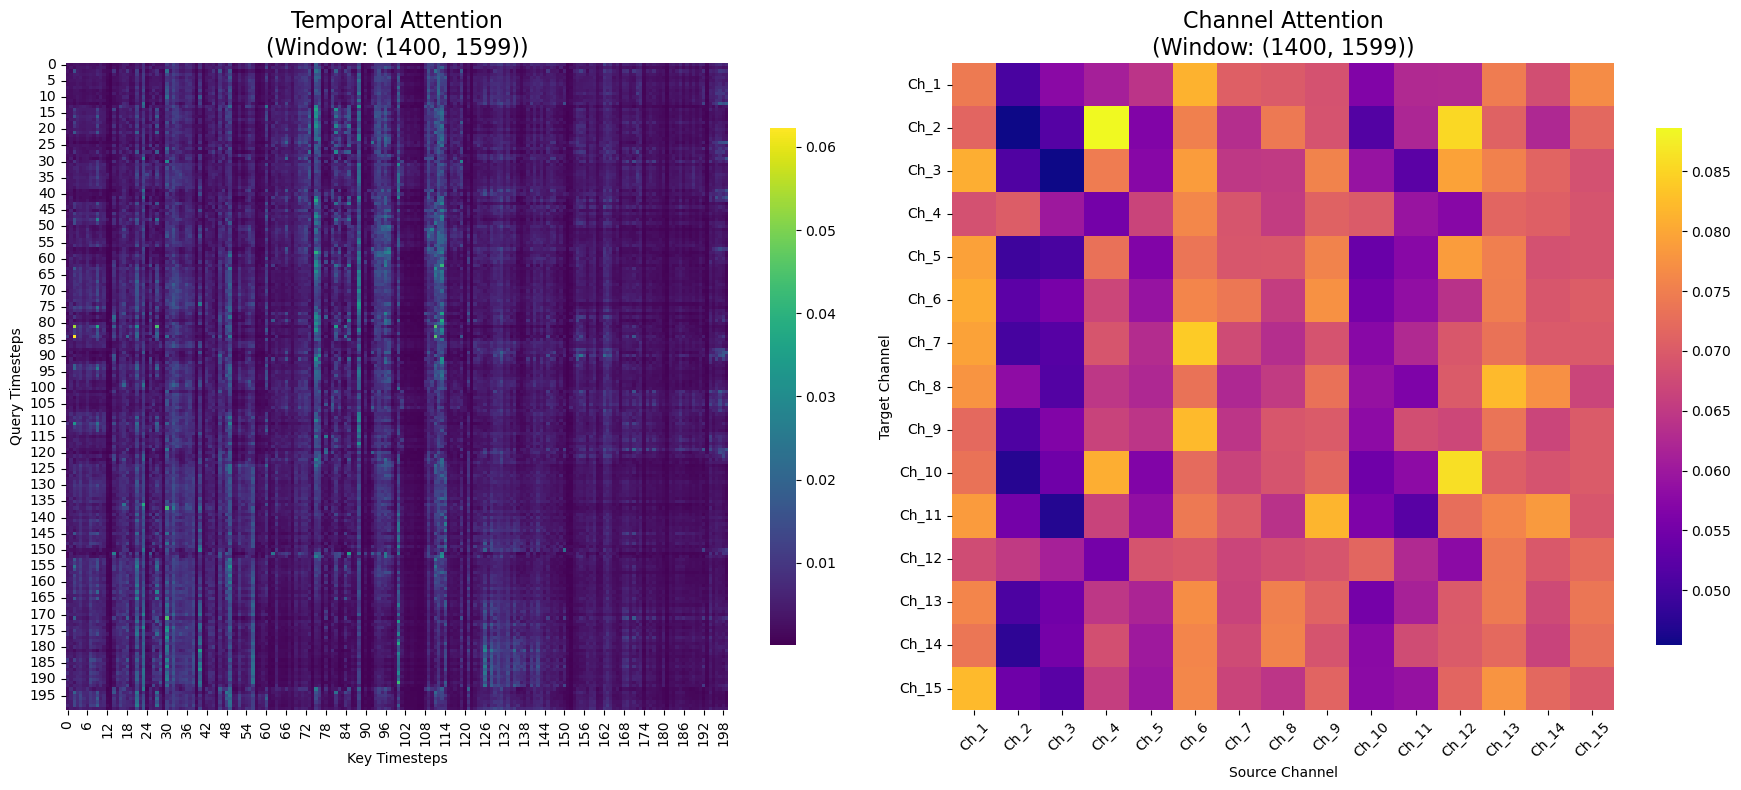

In [37]:
# --- 실행 부분 ---
target_timestamp = 1400
output_folder = r'output\COLLECTOR\Proposed\19032026_121301'

temporal_attention_filepath = os.path.join(output_folder, 'temporal_att_storage.npy')
channel_attention_filepath = os.path.join(output_folder, 'channel_att_storage.npy')
# Gate 가중치가 저장된 경로 추가
gate_weights_filepath = os.path.join(output_folder, 'gate_att_storage.npy') 

visualize_attention_and_gates(
    target_t=target_timestamp, 
    temporal_att_file=temporal_attention_filepath, 
    channel_att_file=channel_attention_filepath,
    gate_weights_file=gate_weights_filepath
)